# Model 1A, Experiment 05: Logistic Regression with Causal Aircraft Rotation

This experiment preserves the 20-field raw Experiment 01 baseline and adds aircraft-rotation state reconstructed at each flight's scheduled-departure cutoff. It compares a compact five-field rotation manifest with all 13 generated rotation fields.

Within five expanding 2019 folds, grid search selects the rotation manifest, passthrough versus training-only L1 top-N feature selection, regularization strength, L1 versus L2 final classification, and class weighting. The winner is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.

Historical BTS contains the final aircraft tail, not a timestamped assignment history. Results are therefore a retrospective upper bound unless the final tail can be shown to equal the assignment available at the prediction cutoff.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score, make_scorer,
    matthews_corrcoef, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and validate the 2019 and 2023 rotation datasets

Only the separately generated rotation datasets are loaded. Validation checks population scope, rotation identities, and causal masking before any model is fitted.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    relative_paths = [
        Path("data/features") / f"{airport}_{year}_departures_rotation.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR]
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures_rotation.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures_rotation.csv"
train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)
print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")

Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures_rotation.csv
Training rows: 107,430; columns: 133
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures_rotation.csv
Validation rows: 109,983; columns: 133


In [4]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "DATE", "Origin", "CRSDepTime", TARGET,
                *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    missing = sorted(required - set(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    cutoff = pd.to_datetime(frame["ROTATION_TARGET_CUTOFF_UTC"], errors="coerce")
    prior_actual = pd.to_datetime(frame["ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"], errors="coerce")
    assert frame["FlightDate"].notna().all() and cutoff.notna().all()
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Origin"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all() and set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    match = pd.to_numeric(frame["ROTATION_MATCH_FOUND"], errors="coerce")
    arrived = pd.to_numeric(frame["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="coerce")
    not_arrived = pd.to_numeric(frame["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="coerce")
    assert match.notna().all() and arrived.notna().all() and not_arrived.notna().all()
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
                   "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15"]
    assert not frame.loc[arrived.eq(0), actual_only].notna().any().any()
    assert prior_actual.loc[arrived.eq(0)].isna().all()
    assert prior_actual.loc[arrived.eq(1)].le(cutoff.loc[arrived.eq(1)]).all()
    status = frame["ROTATION_STATUS"].astype("string")
    assert status.loc[arrived.eq(1)].eq("ARRIVED").all()
    assert status.loc[not_arrived.eq(1)].eq("NOT_ARRIVED").all()
    return {
        "partition": partition, "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame), "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(), "match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()),
        "not_arrived_delay_rate": frame.loc[not_arrived.eq(1), TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate,match_rate,not_arrived_rows,not_arrived_delay_rate
partition,,,,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877,0.9564,2638,0.9977
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364,0.9339,2995,0.9963


## Prediction-time feature manifests

Both candidates retain the exact 20-field raw Experiment 01 baseline. The compact variant adds rotation status plus log scheduled turn, log observable actual turn, log overdue duration, and signed observable inbound arrival delay. The full variant exposes all 13 generated fields. Rotation audit columns, target-flight outcomes, and raw tail identity are forbidden.

In [5]:
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
COMPACT_ROTATION_CATEGORICAL = ["ROTATION_STATUS"]
COMPACT_ROTATION_NUMERIC = [
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
    "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY",
]
FULL_ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
FULL_ROTATION_NUMERIC = [
    column for column in ROTATION_FEATURES
    if column not in FULL_ROTATION_CATEGORICAL
]
ROTATION_VARIANTS = {
    "compact": {"categorical": COMPACT_ROTATION_CATEGORICAL,
                "numeric": COMPACT_ROTATION_NUMERIC},
    "full": {"categorical": FULL_ROTATION_CATEGORICAL,
             "numeric": FULL_ROTATION_NUMERIC},
}
ALL_MODEL_FEATURES = list(dict.fromkeys(
    BASE_CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES
    + FULL_ROTATION_CATEGORICAL + FULL_ROTATION_NUMERIC
))
REQUIRED_COLUMNS = ["FlightDate", "Origin", TARGET, *ALL_MODEL_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    assert not missing, f"{partition} missing model columns: {missing}"

FORBIDDEN_PREDICTORS = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "DepartureDelayGroups",
    "TaxiOut", "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime",
    "ArrDelay", "ArrDelayMinutes", "ArrDel15", "ArrivalDelayGroups",
    "ActualElapsedTime", "AirTime", "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not FORBIDDEN_PREDICTORS.intersection(ALL_MODEL_FEATURES)
manifest_summary = pd.DataFrame({
    name: {
        "raw_baseline_fields": len(BASE_CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES),
        "rotation_fields": len(spec["categorical"]) + len(spec["numeric"]),
        "total_fields": len(BASE_CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES)
                        + len(spec["categorical"]) + len(spec["numeric"]),
    } for name, spec in ROTATION_VARIANTS.items()
}).T
manifest_summary

,raw_baseline_fields,rotation_fields,total_fields
compact,20,5,25
full,20,13,33


## Missingness and expanding-day partitions

No row is dropped for missing predictors. Imputation, missingness indicators, category encoding, scaling, feature selection, and classifier settings are fitted within the 2019 training folds. Complete calendar days remain together.

In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    model_frame = source_frame[REQUIRED_COLUMNS].copy()
    model_frame = model_frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)
    for column in BASE_CATEGORICAL_FEATURES + FULL_ROTATION_CATEGORICAL:
        model_frame[column] = model_frame[column].astype(object)
    for column in BASE_NUMERIC_FEATURES + FULL_ROTATION_NUMERIC:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")
    return model_frame


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))
    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append({
            "fold": fold_number, "train_start": pd.Timestamp(train_days.min()).date(),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(validation_days.min()).date(),
            "validation_end": pd.Timestamp(validation_days.max()).date(),
            "train_rows": len(train_indices), "validation_rows": len(validation_indices),
            "train_delay_rate": targets.iloc[train_indices].mean(),
            "validation_delay_rate": targets.iloc[validation_indices].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[ALL_MODEL_FEATURES].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[ALL_MODEL_FEATURES].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()
temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
display(missing_summary[missing_summary.sum(axis=1).gt(0)])
fold_summary

,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
ROTATION_INBOUND_ORIGIN,4689,7267
ROTATION_SCHEDULED_TURN_MINUTES,4689,7267
ROTATION_INBOUND_OVERDUE_MINUTES,4689,7267
ROTATION_LOG_INBOUND_OVERDUE_MINUTES,4689,7267
ROTATION_ACTUAL_TURN_MINUTES,7327,10262


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Training-only grid search and feature selection

Each manifest compares all nonconstant prepared columns with L1-ranked top-50, top-100, and top-200 alternatives. A callable caps top-N at the number of columns available inside each fold. Feature selection is part of the pipeline, so it never sees a held-out fold. Average precision selects the winner.

In [7]:
def top_50(X):
    return min(50, X.shape[1])


def top_100(X):
    return min(100, X.shape[1])


def top_200(X):
    return min(200, X.shape[1])


TOP_N_FUNCTIONS = [top_50, top_100, top_200]


def make_logistic_search(rotation_spec):
    categorical_features = BASE_CATEGORICAL_FEATURES + list(rotation_spec["categorical"])
    numeric_features = BASE_NUMERIC_FEATURES + list(rotation_spec["numeric"])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer([
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ], remainder="drop")
    selector = SelectFromModel(
        estimator=LogisticRegression(
            C=0.1, l1_ratio=1.0, solver="liblinear", class_weight=None,
            max_iter=5_000, random_state=RANDOM_STATE,
        ),
        threshold=-np.inf, max_features=top_100,
    )
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("feature_selection", "passthrough"),
        ("classifier", LogisticRegression(
            solver="liblinear", max_iter=5_000, random_state=RANDOM_STATE
        )),
    ])
    parameter_grid = [
        {
            "feature_selection": ["passthrough"],
            "classifier__C": [0.01, 0.1, 1.0, 10.0],
            "classifier__l1_ratio": [1.0, 0.0],
            "classifier__class_weight": [None, "balanced"],
        },
        {
            "feature_selection": [selector],
            "feature_selection__max_features": TOP_N_FUNCTIONS,
            "classifier__C": [0.01, 0.1, 1.0, 10.0],
            "classifier__l1_ratio": [0.0],
            "classifier__class_weight": [None, "balanced"],
        },
    ]
    scoring = {
        "average_precision": "average_precision", "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": "recall", "f1": "f1",
        "mcc": make_scorer(matthews_corrcoef), "neg_brier": "neg_brier_score",
    }
    search = GridSearchCV(
        pipeline, parameter_grid, scoring=scoring, refit="average_precision",
        cv=temporal_splits, n_jobs=N_JOBS, pre_dispatch=N_JOBS, verbose=1,
        return_train_score=False, error_score="raise",
    )
    return search, categorical_features, numeric_features, sum(
        len(list(ParameterGrid(grid))) for grid in parameter_grid
    )


variant_searches, variant_features, search_rows, cv_result_frames = {}, {}, [], []
total_search_start = perf_counter()
for variant_name, rotation_spec in ROTATION_VARIANTS.items():
    search, categorical_features, numeric_features, candidate_count = make_logistic_search(rotation_spec)
    selected_columns = categorical_features + numeric_features
    variant_start = perf_counter()
    search.fit(X_train[selected_columns], y_train)
    variant_seconds = perf_counter() - variant_start
    variant_searches[variant_name] = search
    variant_features[variant_name] = {"categorical": categorical_features,
                                      "numeric": numeric_features,
                                      "all": selected_columns}
    results = pd.DataFrame(search.cv_results_)
    results["rotation_variant"] = variant_name
    cv_result_frames.append(results)
    search_rows.append({
        "rotation_variant": variant_name,
        "rotation_fields": len(rotation_spec["categorical"]) + len(rotation_spec["numeric"]),
        "candidates": candidate_count, "temporal_fits": candidate_count * len(temporal_splits),
        "best_mean_cv_ap": search.best_score_, "seconds": variant_seconds,
    })
search_seconds = perf_counter() - total_search_start
search_summary = pd.DataFrame(search_rows).set_index("rotation_variant")
search_summary

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,rotation_fields,candidates,temporal_fits,best_mean_cv_ap,seconds
rotation_variant,,,,,
compact,5,40,200,0.5898,508.9944
full,13,40,200,0.5930,253.3822


In [8]:
selected_variant = search_summary["best_mean_cv_ap"].idxmax()
selected_search = variant_searches[selected_variant]
best_logistic_pipeline = selected_search.best_estimator_
selected_feature_columns = variant_features[selected_variant]["all"]
selected_rotation_features = (ROTATION_VARIANTS[selected_variant]["categorical"]
                              + ROTATION_VARIANTS[selected_variant]["numeric"])
cv_results = pd.concat(cv_result_frames, ignore_index=True)
cv_results["classifier_penalty"] = cv_results["param_classifier__l1_ratio"].map({1.0: "l1", 0.0: "l2"})
cv_results["selection_strategy"] = cv_results["param_feature_selection"].map(
    lambda value: "passthrough" if value == "passthrough" else "L1 top-N"
)
cv_results["top_n"] = cv_results.get("param_feature_selection__max_features", pd.Series(index=cv_results.index)).map(
    lambda value: getattr(value, "__name__", None)
)
result_columns = [
    "rotation_variant", "mean_test_average_precision", "std_test_average_precision",
    "mean_test_roc_auc", "mean_test_balanced_accuracy", "mean_test_precision",
    "mean_test_recall", "mean_test_f1", "mean_test_mcc", "mean_test_neg_brier",
    "selection_strategy", "top_n", "param_classifier__C",
    "classifier_penalty", "param_classifier__class_weight",
]
display(cv_results.sort_values("mean_test_average_precision", ascending=False)[result_columns].head(15))
print(f"Total search and refit time: {search_seconds:,.1f} seconds")
print(f"Selected rotation variant: {selected_variant}")
print(f"Selected mean temporal-validation AP: {selected_search.best_score_:.4f}")
display(pd.Series(selected_search.best_params_, name="value").to_frame())

,rotation_variant,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,selection_strategy,top_n,param_classifier__C,classifier_penalty,param_classifier__class_weight
49,full,0.5930,0.0572,0.7816,0.6449,0.8161,0.3058,0.4431,0.4417,-0.1125,passthrough,NaN,1.0000,l2,NaN
70,full,0.5930,0.0572,0.7816,0.6449,0.8161,0.3058,0.4431,0.4417,-0.1125,L1 top-N,top_200,1.0000,l2,NaN
76,full,0.5929,0.0573,0.7815,0.6451,0.8134,0.3065,0.4433,0.4410,-0.1125,L1 top-N,top_200,10.0000,l2,NaN
53,full,0.5929,0.0573,0.7815,0.6451,0.8134,0.3065,0.4433,0.4410,-0.1125,passthrough,NaN,10.0000,l2,NaN
52,full,0.5924,0.0582,0.7811,0.6454,0.8136,0.3070,0.4444,0.4419,-0.1123,passthrough,NaN,10.0000,l1,NaN
64,full,0.5923,0.0571,0.7820,0.6418,0.8213,0.2985,0.4363,0.4383,-0.1127,L1 top-N,top_200,0.1000,l2,NaN
45,full,0.5923,0.0571,0.7820,0.6418,0.8213,0.2985,0.4363,0.4383,-0.1127,passthrough,NaN,0.1000,l2,NaN
48,full,0.5920,0.0553,0.7808,0.6410,0.8348,0.2958,0.4351,0.4412,-0.1128,passthrough,NaN,1.0000,l1,NaN
75,full,0.5906,0.0572,0.7797,0.6437,0.8210,0.3027,0.4406,0.4412,-0.1128,L1 top-N,top_100,10.0000,l2,NaN
69,full,0.5903,0.0573,0.7796,0.6432,0.8228,0.3014,0.4396,0.4411,-0.1128,L1 top-N,top_100,1.0000,l2,NaN


Total search and refit time: 762.4 seconds
Selected rotation variant: full
Selected mean temporal-validation AP: 0.5930


,value
classifier__C,1.0000
classifier__class_weight,None
classifier__l1_ratio,0.0000
feature_selection,passthrough


In [9]:
def get_retained_feature_names(fitted_pipeline):
    encoded_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    nonconstant_names = encoded_names[fitted_pipeline.named_steps["variance_filter"].get_support()]
    selection_step = fitted_pipeline.named_steps["feature_selection"]
    retained = nonconstant_names if selection_step == "passthrough" else nonconstant_names[selection_step.get_support()]
    return encoded_names, nonconstant_names, retained


encoded_feature_names, nonconstant_feature_names, selected_feature_names = get_retained_feature_names(best_logistic_pipeline)
selection_step = best_logistic_pipeline.named_steps["feature_selection"]
selected_strategy = ("passthrough" if selection_step == "passthrough"
                     else getattr(selected_search.best_params_["feature_selection__max_features"], "__name__", "top-N"))
classifier = best_logistic_pipeline.named_steps["classifier"]
nonzero_mask = ~np.isclose(classifier.coef_[0], 0.0)
feature_selection_summary = pd.Series({
    "rotation_variant": selected_variant, "rotation_source_fields": len(selected_rotation_features),
    "selection_strategy": selected_strategy, "encoded_columns": len(encoded_feature_names),
    "nonconstant_columns": len(nonconstant_feature_names),
    "columns_after_selection": len(selected_feature_names),
    "nonzero_final_coefficients": int(nonzero_mask.sum()),
}, name="value")
feature_selection_summary.to_frame()

,value
rotation_variant,full
rotation_source_fields,13
selection_strategy,passthrough
encoded_columns,172
nonconstant_columns,172
columns_after_selection,172
nonzero_final_coefficients,172


## Select the operating threshold from 2019 only

The selected pipeline is cloned into each temporal fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities. The same fold fits also measure selected-feature stability.

In [10]:
oof_probabilities = np.full(len(y_train), np.nan)
fold_selected_feature_sets = []
for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_logistic_pipeline)
    fold_model.fit(X_train.iloc[train_indices][selected_feature_columns], y_train.iloc[train_indices])
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices][selected_feature_columns]
    )[:, 1]
    fold_selected_feature_sets.append(set(get_retained_feature_names(fold_model)[2]))
oof_mask = np.isfinite(oof_probabilities)
oof_y, oof_p = y_train.to_numpy()[oof_mask], oof_probabilities[oof_mask]
threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold, "accuracy": accuracy_score(oof_y, predictions),
        "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
        "precision": precision_score(oof_y, predictions, zero_division=0),
        "recall": recall_score(oof_y, predictions, zero_division=0),
        "f1": f1_score(oof_y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(oof_y, predictions),
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])
stability_rows = []
for left in range(len(fold_selected_feature_sets)):
    for right in range(left + 1, len(fold_selected_feature_sets)):
        a, b = fold_selected_feature_sets[left], fold_selected_feature_sets[right]
        stability_rows.append({"fold_pair": f"{left+1}-{right+1}",
                               "jaccard_similarity": len(a & b) / len(a | b)})
feature_selection_stability = pd.DataFrame(stability_rows)
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(threshold_results.sort_values("f1", ascending=False).head(10))
feature_selection_stability.describe()

Threshold-selection rows: 89,693
Training-only selected threshold: 0.26


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
21,0.2600,0.8228,0.7028,0.5281,0.5108,0.5193,0.4108
22,0.2700,0.8269,0.6997,0.5419,0.4961,0.5180,0.4133
20,0.2500,0.8171,0.7042,0.5119,0.5234,0.5176,0.4048
23,0.2800,0.8311,0.6971,0.5569,0.4828,0.5172,0.4170
24,0.2900,0.8349,0.6948,0.5724,0.4707,0.5166,0.4210
19,0.2400,0.8111,0.7058,0.4965,0.5372,0.5160,0.3994
25,0.3000,0.8375,0.6920,0.5849,0.4591,0.5144,0.4230
18,0.2300,0.8044,0.7071,0.4811,0.5513,0.5138,0.3935
26,0.3100,0.8404,0.6892,0.5994,0.4474,0.5123,0.4257
17,0.2200,0.7972,0.7090,0.4663,0.5678,0.5121,0.3886


,jaccard_similarity
count,10.0000
mean,0.9709
std,0.0160
min,0.9401
25%,0.9634
50%,0.9753
75%,0.9846
max,0.9877


## Evaluate the untouched 2023 external-validation partition

The selected 2019 model and threshold are applied once to 2023. A diagnostic excluding `NOT_ARRIVED` rows is reported after the primary overall result; it is not used to retune the experiment.

In [11]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name, "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


prediction_start = perf_counter()
validation_probabilities = best_logistic_pipeline.predict_proba(
    X_validation[selected_feature_columns]
)[:, 1]
prediction_seconds = perf_counter() - prediction_start
dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train[selected_feature_columns], y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation[selected_feature_columns])[:, 1]
evaluation_results = pd.DataFrame([
    evaluate_probabilities(y_validation, dummy_probabilities, "Dummy (2019 prior)", 0.50),
    evaluate_probabilities(y_validation, validation_probabilities, "Logistic (default)", 0.50),
    evaluate_probabilities(y_validation, validation_probabilities,
                           "Logistic (training-selected)", selected_threshold),
]).set_index("model")
print(f"2023 probability prediction time: {prediction_seconds:,.3f} seconds")
evaluation_results

2023 probability prediction time: 0.173 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Logistic (default),0.5000,0.8251,0.6486,0.8539,0.3138,0.4589,0.4483,0.7932,0.6515,0.1316
Logistic (training-selected),0.2600,0.8053,0.7115,0.5988,0.5336,0.5644,0.4407,0.7932,0.6515,0.1316


In [12]:
not_arrived_mask = X_validation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"].eq(1).to_numpy()
subgroup_rows = []
for name, mask in [("all 2023 rows", np.ones(len(y_validation), dtype=bool)),
                   ("excluding NOT_ARRIVED", ~not_arrived_mask)]:
    subgroup_y = y_validation.to_numpy()[mask]
    subgroup_p = validation_probabilities[mask]
    subgroup_rows.append({
        "population": name, "rows": int(mask.sum()), "prevalence": subgroup_y.mean(),
        "average_precision": average_precision_score(subgroup_y, subgroup_p),
        "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
        "brier_score": brier_score_loss(subgroup_y, subgroup_p),
    })
subgroup_results = pd.DataFrame(subgroup_rows).set_index("population")
not_arrived_summary = pd.Series({
    "rows": int(not_arrived_mask.sum()),
    "row_percent": not_arrived_mask.mean() * 100,
    "delay_rate": y_validation.to_numpy()[not_arrived_mask].mean(),
}, name="2023 NOT_ARRIVED")
display(not_arrived_summary.to_frame())
subgroup_results

,2023 NOT_ARRIVED
rows,"2,995.0000"
row_percent,2.7231
delay_rate,0.9963


,rows,prevalence,average_precision,roc_auc,brier_score
population,,,,,
all 2023 rows,109983,0.2364,0.6515,0.7932,0.1316
excluding NOT_ARRIVED,106988,0.2151,0.5620,0.7665,0.1352


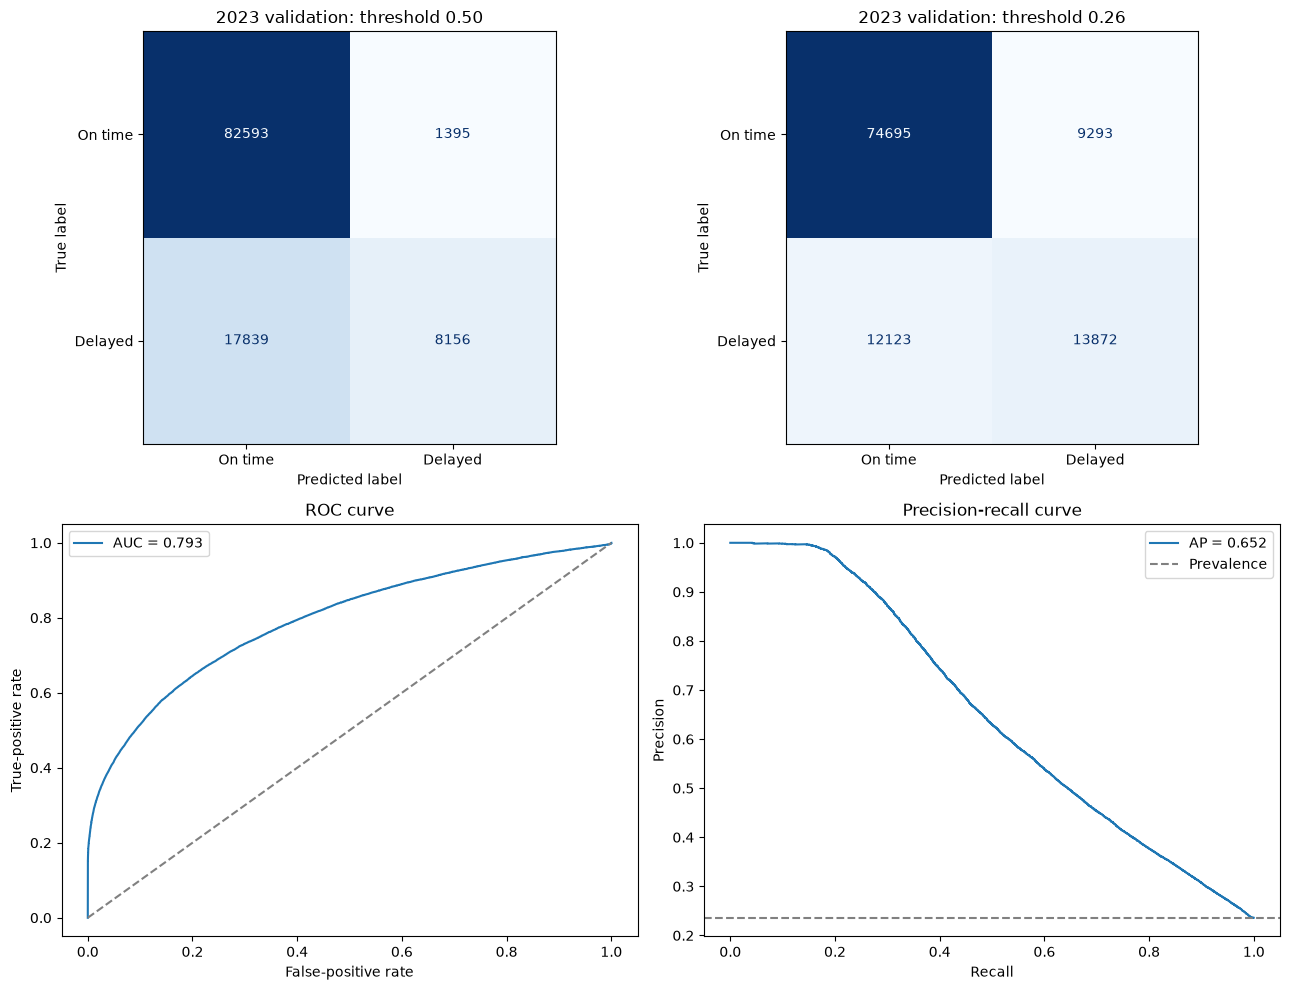

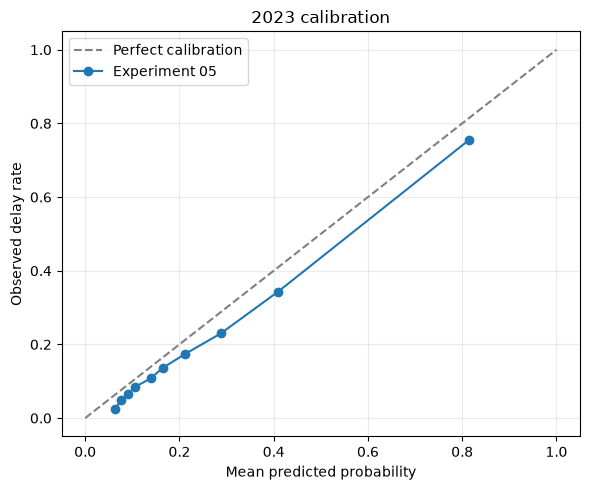

In [13]:
ranking_row = evaluation_results.loc["Logistic (default)"]
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("2023 validation: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate, label=f"AUC = {ranking_row['roc_auc']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision, label=f"AP = {ranking_row['average_precision']:.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1, 1].legend()
fig.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(calibration_predicted, calibration_observed, marker="o", label="Experiment 05")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Inspect selected standardized coefficients

Coefficient signs describe associations within this encoded model, not causes. The not-arrived state is operationally strong, but its coefficient and the overall scores retain the final-tail assignment caveat.

In [14]:
coefficient_series = pd.Series(classifier.coef_[0], index=selected_feature_names, name="coefficient")
coefficient_table = (coefficient_series.rename_axis("feature").reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False))
display(coefficient_table.head(25))
rotation_coefficients = coefficient_table[
    coefficient_table["feature"].str.contains("ROTATION_", regex=False)
]
rotation_coefficients

,feature,coefficient,abs_coefficient
159,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,3.7238,3.7238
156,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-3.6033,3.6033
26,categorical__Reporting_Airline_OH,-1.1950,1.1950
45,categorical__Dest_HNL,1.1485,1.1485
152,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.1204,1.1204
154,numeric__ROTATION_LOG_INBOUND_OVERDUE_MINUTES,-1.0239,1.0239
79,categorical__ROTATION_STATUS_ARRIVED,-0.9410,0.9410
99,categorical__ROTATION_INBOUND_ORIGIN_HNL,-0.8057,0.8057
28,categorical__Reporting_Airline_YX,-0.7944,0.7944
7,categorical__Month_8,0.6452,0.6452


,feature,coefficient,abs_coefficient
159,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,3.7238,3.7238
156,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-3.6033,3.6033
152,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.1204,1.1204
154,numeric__ROTATION_LOG_INBOUND_OVERDUE_MINUTES,-1.0239,1.0239
79,categorical__ROTATION_STATUS_ARRIVED,-0.9410,0.9410
...,...,...,...
111,categorical__ROTATION_INBOUND_ORIGIN_MSY,-0.0152,0.0152
98,categorical__ROTATION_INBOUND_ORIGIN_FLL,-0.0151,0.0151
115,categorical__ROTATION_INBOUND_ORIGIN_PBI,-0.0098,0.0098
150,numeric__ROTATION_SCHEDULED_TURN_MINUTES,0.0095,0.0095


In [15]:
default_row = evaluation_results.loc["Logistic (default)"]
selected_row = evaluation_results.loc["Logistic (training-selected)"]
appendix_d_summary = pd.Series({
    "selected_rotation_variant": selected_variant,
    "rotation_source_fields": len(selected_rotation_features),
    "selection_strategy": selected_strategy,
    "prepared_columns": len(encoded_feature_names),
    "selected_columns": len(selected_feature_names),
    "nonzero_coefficients": int(nonzero_mask.sum()),
    "classifier_C": selected_search.best_params_["classifier__C"],
    "classifier_penalty": "l1" if selected_search.best_params_["classifier__l1_ratio"] == 1.0 else "l2",
    "class_weight": str(selected_search.best_params_["classifier__class_weight"]),
    "training_cv_ap": selected_search.best_score_,
    "validation_prevalence": y_validation.mean(),
    "validation_ap": default_row["average_precision"],
    "validation_roc_auc": default_row["roc_auc"],
    "validation_brier": default_row["brier_score"],
    "validation_ap_excluding_not_arrived": subgroup_results.loc["excluding NOT_ARRIVED", "average_precision"],
    "selected_threshold": selected_threshold,
    "default_accuracy": default_row["accuracy"],
    "default_balanced_accuracy": default_row["balanced_accuracy"],
    "default_precision": default_row["precision"],
    "default_recall": default_row["recall"],
    "default_f1": default_row["f1"], "default_mcc": default_row["mcc"],
    "selected_accuracy": selected_row["accuracy"],
    "selected_balanced_accuracy": selected_row["balanced_accuracy"],
    "selected_precision": selected_row["precision"],
    "selected_recall": selected_row["recall"],
    "selected_f1": selected_row["f1"], "selected_mcc": selected_row["mcc"],
    "search_seconds": search_seconds, "prediction_seconds": prediction_seconds,
}, name="Experiment 05 Appendix E values")
appendix_d_summary.to_frame()

,Experiment 05 Appendix E values
selected_rotation_variant,full
rotation_source_fields,13
selection_strategy,passthrough
prepared_columns,172
selected_columns,172
nonzero_coefficients,172
classifier_C,1.0000
classifier_penalty,l2
class_weight,None
training_cv_ap,0.5930


## Experiment 05 interpretation checklist

1. Does the compact or full rotation manifest win in the 2019 temporal folds?
2. Does top-N feature selection outperform using every nonconstant prepared column?
3. Does the gain over Experiments 01 and 04 persist in 2023 AP, ROC AUC, Brier score, F1, and MCC?
4. Does ranking improve among flights whose aircraft had already arrived, rather than only through `NOT_ARRIVED`?
5. Which rotation fields survive training-only selection, and are their signs operationally plausible?
6. Are the gains large enough to justify a live aircraft-assignment and arrival-event feed?

The 2023 results may compare this completed experiment with earlier Model 1A experiments but must not be used to refit or retune Experiment 05. The 2024 dataset remains untouched.